# 运动学基础与位姿变换

## 位姿变换

In [ ]:
import roboticstoolbox as rtb
# 空间变换数学包
from spatialmath import *
import numpy as np
%matplotlib auto
# Jupyter Notebook 的魔法命令，用于设置 Matplotlib 图形的显示方式
# auto 会确保 Matplotlib 图形的显示方式适应当前环境

### 二维位姿变换：

SE2 平移旋转一起

In [36]:
# 变换 = SE2(x平移，Y平移，旋转 180°/3 = 60°)
T = SE2(1, 2, np.pi/3)

# 齐次变换矩阵
# cos(60), -sin(30),  m(x)
# sim(30),  cos(60),  m(y)
# 0      ,        0,  1     
T
# help(SE2)

   0.5      -0.866     1         
   0.866     0.5       2         
   0         0         1         


SE2 图形化表示

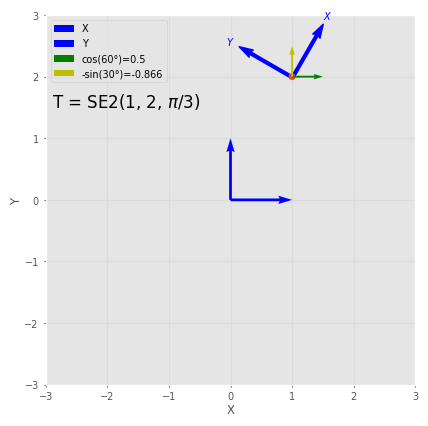

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from spatialmath import SE2

# %matplotlib inline 确保图形直接显示在 Jupyter 中
%matplotlib inline

# 创建 SE2 变换
T = SE2(1, 2, np.pi/3)

# 创建图形和轴
fig, ax = plt.subplots()

# 绘制原始坐标系
ax.quiver(0, 0, 1, 0, angles='xy', scale_units='xy', scale=1, color='b', label='X')
ax.quiver(0, 0, 0, 1, angles='xy', scale_units='xy', scale=1, color='b', label='Y')

# 绘制 SE2 变换后的坐标系
T.plot(ax=ax, length=1)  # length 用来设置箭头的长度

# 计算角度对应的坐标
cos60 = np.cos(np.pi/3)
sin30 = np.sin(np.pi/6)  # 30° 的正弦
neg_sin30 = -np.sin(np.pi/6)  # 30° 的负正弦

# 绘制 cos(60°), -sin(30°) 的向量
ax.quiver(1, 2, cos60, 0, angles='xy', scale_units='xy', scale=1, color='g', label='cos(60°)=0.5', width=0.005)
ax.quiver(1, 2, 0, sin30, angles='xy', scale_units='xy', scale=1, color='y', label='-sin(30°)=-0.866', width=0.005)

# 标注变换公式
ax.text(-2.9, 1.5, r"T = SE2(1, 2, $\pi/3$)", color="black", fontsize=12)

# 设置图形的范围和显示
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.legend()
ax.grid(True)

# 显示图形
plt.show()

### 坐标点变换

In [37]:
initial_point = np.array([[0],[0],[1]])
initial_point

array([[0],
       [0],
       [1]])

In [38]:
initial_point.shape

(3, 1)

使用 T 进行变换后，只有平移生效，旋转不生效

In [39]:
post_point = np.array(T).dot(initial_point)
post_point

array([[1.],
       [2.],
       [1.]])

对变换矩阵求逆，从 post_point 获得，初始矩阵坐标

In [49]:
from numpy.linalg import inv
print("T：\r\n", np.array(T))
print("\r\nT′：\r\n", inv(np.array(T)))
print("\r\ninitial_point：\r\n", initial_point)
print("\r\norigin point (post_point.inv)：\r\n", inv(np.array(T)).dot(post_point))

T：
 [[ 0.5       -0.8660254  1.       ]
 [ 0.8660254  0.5        2.       ]
 [ 0.         0.         1.       ]]

T′：
 [[ 0.5         0.8660254  -2.23205081]
 [-0.8660254   0.5        -0.1339746 ]
 [ 0.          0.          1.        ]]

initial_point：
 [[0]
 [0]
 [1]]

origin point (post_point.inv)：
 [[-4.4408921e-16]
 [ 0.0000000e+00]
 [ 1.0000000e+00]]


### SO 仅旋转，transl2 仅平移

In [50]:
T = SO2(np.pi/3)
print("T:\r\n", T)

T:
    0.5      -0.866     
   0.866     0.5       



In [54]:
# Tx 仅在 x 轴上平移
from spatialmath.base import *
T = SE2.Tx(2)
print("Tx:\r\n", T)
T = SE2.Ty(2)
print("Ty:\r\n", T)
# 同时进行 x 轴 和 y 轴的平移
T = transl2([1, 2])
print("transl2:\r\n", T)

Tx:
    1         0         2         
   0         1         0         
   0         0         1         

Ty:
    1         0         0         
   0         1         2         
   0         0         1         

transl2:
 [[1. 0. 1.]
 [0. 1. 2.]
 [0. 0. 1.]]


### 3维变换

In [67]:
# Tx 仅在 x 轴上旋转
from spatialmath.base import *
T = SE3.Rx(np.pi/3)
print("Rx:\r\n", T)


Rx:
    1         0         0         0         
   0         0.5      -0.866     0         
   0         0.866     0.5       0         
   0         0         0         1         



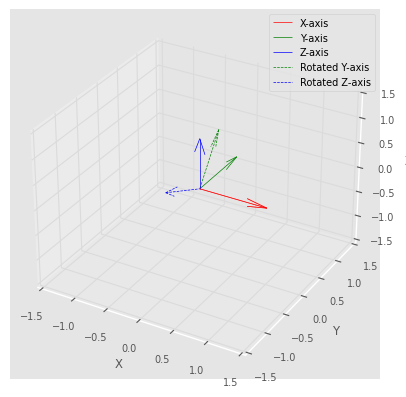

In [66]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from spatialmath import SE3

# 创建 SE3 绕 x 轴旋转的变换矩阵
T = SE3.Rx(np.pi/3)

# 生成旋转前的坐标系
origin = np.array([0, 0, 0])
x_axis = np.array([1, 0, 0])
y_axis = np.array([0, 1, 0])
z_axis = np.array([0, 0, 1])

# 将坐标轴转换为齐次坐标（4x1），通过在最后添加 1
y_axis_homogeneous = np.array([y_axis[0], y_axis[1], y_axis[2], 1])
z_axis_homogeneous = np.array([z_axis[0], z_axis[1], z_axis[2], 1])

# 创建图形和 3D 轴
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 绘制原始坐标系（红色、绿色、蓝色轴）
ax.quiver(origin[0], origin[1], origin[2], x_axis[0], x_axis[1], x_axis[2], color='r', label='X-axis')
ax.quiver(origin[0], origin[1], origin[2], y_axis[0], y_axis[1], y_axis[2], color='g', label='Y-axis')
ax.quiver(origin[0], origin[1], origin[2], z_axis[0], z_axis[1], z_axis[2], color='b', label='Z-axis')

# 应用 Rx 变换（绕 x 轴旋转）
rotated_y = np.dot(T.A, y_axis_homogeneous)  # 将 y 轴旋转
rotated_z = np.dot(T.A, z_axis_homogeneous)  # 将 z 轴旋转

# 绘制旋转后的坐标系
ax.quiver(origin[0], origin[1], origin[2], x_axis[0], x_axis[1], x_axis[2], color='r', alpha=0.5)
ax.quiver(origin[0], origin[1], origin[2], rotated_y[0], rotated_y[1], rotated_y[2], color='g', label='Rotated Y-axis', linestyle='--')
ax.quiver(origin[0], origin[1], origin[2], rotated_z[0], rotated_z[1], rotated_z[2], color='b', label='Rotated Z-axis', linestyle='--')

# 设置图形的范围
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-1.5, 1.5])
ax.set_zlim([-1.5, 1.5])

# 设置图形标签
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# 添加图例
ax.legend()

# 显示图形
plt.show()


In [ ]:
# Tx 仅在 x 轴上旋转（齐次矩阵）
from spatialmath.base import *
T = rotx(np.pi/3)
# 仅旋转矩阵
print("rotx:\r\n", T)
T = SE3.Ry(np.pi/3)
print("\r\nRy:\r\n", T)
T = SE3.Rz(np.pi/3)
print("\r\nRz:\r\n", T)

rotx:
 [[ 1.         0.         0.       ]
 [ 0.         0.5       -0.8660254]
 [ 0.         0.8660254  0.5      ]]

Ry:
    0.5       0         0.866     0         
   0         1         0         0         
  -0.866     0         0.5       0         
   0         0         0         1         


Rz:
    0.5      -0.866     0         0         
   0.866     0.5       0         0         
   0         0         1         0         
   0         0         0         1         

